BLOCK 1: Mount Google Drive

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


BLOCK 2: Set Dataset Path & Basic Checks

In [5]:
# Set dataset path (change folder/file name as per your Drive)
DATASET_PATH = "/content/drive/MyDrive/Project/Dataset"

import os

# Check if file exists
assert os.path.exists(DATASET_PATH), "Dataset not found! Check path."
print("Dataset found successfully ✅")


Dataset found successfully ✅


🔹 BLOCK 3: Import Required Libraries

In [6]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & metrics
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


BLOCK 4: Load Dataset

In [8]:
import os
import pandas as pd

# Dataset directory (your given path)
DATASET_DIR = "/content/drive/MyDrive/Project/Dataset"

# List all files in the directory
files = os.listdir(DATASET_DIR)
print("Files found in dataset directory:", files)

# Automatically pick the first CSV file
csv_files = [f for f in files if f.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ No CSV file found in the Dataset folder")

DATASET_PATH = os.path.join(DATASET_DIR, csv_files[0])
print("Using dataset file:", DATASET_PATH)

# Load the dataset
df = pd.read_csv(DATASET_PATH)

# Display basic information
print("Dataset loaded successfully ✅")
print("Shape of dataset:", df.shape)
df.head()


Files found in dataset directory: ['Pheno.csv', 'myGM.csv', 'myGD']
Using dataset file: /content/drive/MyDrive/Project/Dataset/Pheno.csv
Dataset loaded successfully ✅
Shape of dataset: (1944, 10)


,Name,Taxa,Family,Location,Env,Yield,TSTWT,Protein,Height,DTH
0,DHARWAR_57,EA_51,DHARWAR,Spillman,2014,2.211565,58.602659,13.448999,32.833187,175.789643
1,DHARWAR_58,EA_52,DHARWAR,Spillman,2014,1.847965,57.365959,13.440999,35.093187,175.792643
2,DHARWAR_59,EA_53,DHARWAR,Spillman,2014,2.414365,56.565959,12.640999,35.093187,177.792643
3,DHARWAR_60,EA_54,DHARWAR,Spillman,2014,1.990735,56.165959,13.240999,35.093187,177.792643
4,DHARWAR_61,EA_55,DHARWAR,Spillman,2014,1.730065,56.165959,13.841399,33.093187,175.792643


BLOCK 5: Inspect Dataset & Identify Target Column

In [9]:
# Display column names
df.columns


Index(['Name', 'Taxa', 'Family', 'Location', 'Env', 'Yield', 'TSTWT',
       'Protein', 'Height', 'DTH'],
      dtype='object')

BLOCK 6: Define Target & Feature Matrix

In [10]:
TARGET_COLUMN = df.columns[-1]  # assumes last column is target (safe default)

X = df.drop(columns=[TARGET_COLUMN]).values
y = df[TARGET_COLUMN].values.reshape(-1, 1)

print("Target column:", TARGET_COLUMN)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Target column: DTH
Feature matrix shape: (1944, 9)
Target shape: (1944, 1)


BLOCK 7: Min–Max Scaling (Features & Target)

In [15]:
import numpy as np
import pandas as pd

# Identify target column safely (last column)
TARGET_COLUMN = df.columns[-1]

# Create feature DataFrame
X_df = df.drop(columns=[TARGET_COLUMN])

# One-hot encode all categorical columns (removes 'DHARWAR_57')
X_encoded = pd.get_dummies(X_df)

# Ensure all features are numeric
assert X_encoded.select_dtypes(include=['object']).empty, \
    "Non-numeric columns still present!"

# Convert to NumPy float array
X = X_encoded.to_numpy(dtype=np.float64)

print("Block 7 completed successfully ✅")
print("Feature matrix shape:", X.shape)
print("Feature data type:", X.dtype)



Block 7 completed successfully ✅
Feature matrix shape: (1944, 1328)
Feature data type: float64


BLOCK 8: Min–Max Scaling (NOW SAFE)

In [16]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y)

print("Scaling completed successfully ✅")


Scaling completed successfully ✅


BLOCK 9: Train–Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1555, 1328)
Test shape: (389, 1328)


BLOCK 10: Standardization (After Split)

In [18]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)


BLOCK 11: Convert to PyTorch Tensors

In [19]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


BLOCK 12: Dataset & DataLoader

In [20]:
from torch.utils.data import Dataset, DataLoader

class AgronomyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AgronomyDataset(X_train_t, y_train_t)
test_dataset = AgronomyDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


BLOCK 13: Define MLP Model

In [21]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(input_dim=X_train.shape[1])
print(model)


MLP(
  (model): Sequential(
    (0): Linear(in_features=1328, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


🔹 BLOCK 14: Loss Function & Optimizer

In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


BLOCK 15: Training Loop

In [23]:
EPOCHS = 100
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}")


Epoch 10/100, Loss: 0.0061
Epoch 20/100, Loss: 0.0030
Epoch 30/100, Loss: 0.0019
Epoch 40/100, Loss: 0.0015
Epoch 50/100, Loss: 0.0010
Epoch 60/100, Loss: 0.0010
Epoch 70/100, Loss: 0.0007
Epoch 80/100, Loss: 0.0007
Epoch 90/100, Loss: 0.0003
Epoch 100/100, Loss: 0.0007


BLOCK 16: Training Loss Plot

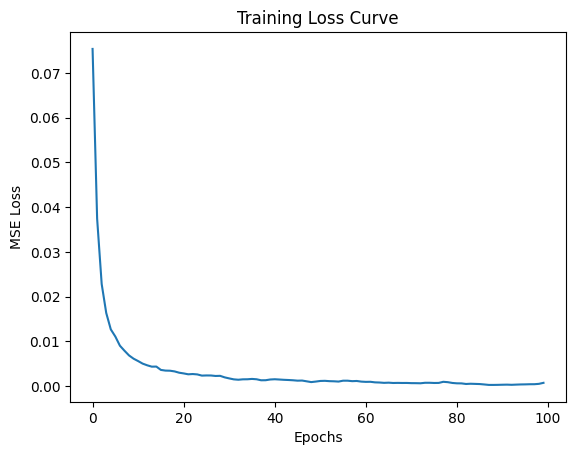

In [24]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()


BLOCK 17: Model Evaluation

In [25]:
model.eval()
predictions = []

with torch.no_grad():
    for xb, _ in test_loader:
        predictions.append(model(xb))

predictions = torch.cat(predictions).numpy()
y_test_np = y_test_t.numpy()


BLOCK 18: Inverse Scaling & Metrics

In [26]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

pred_inv = target_scaler.inverse_transform(predictions)
y_test_inv = target_scaler.inverse_transform(y_test_np)

r2 = r2_score(y_test_inv, pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
corr = np.corrcoef(y_test_inv.flatten(), pred_inv.flatten())[0, 1]

print("R² Score:", r2)
print("RMSE:", rmse)
print("Correlation:", corr)


R² Score: 0.552448034286499
RMSE: 5.554477006274526
Correlation: 0.7792294052512864


BLOCK 19: True vs Predicted Plot

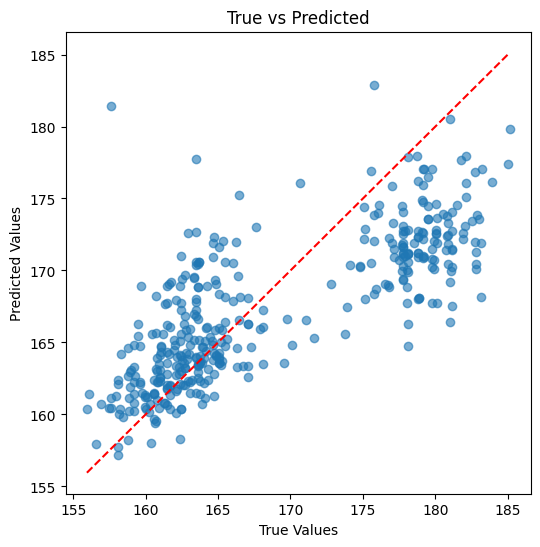

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, pred_inv, alpha=0.6)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")

min_val = min(y_test_inv.min(), pred_inv.min())
max_val = max(y_test_inv.max(), pred_inv.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()
